<a href="https://colab.research.google.com/github/liber-craft-co-ltd/book_impress_it-basic-education-ai/blob/main/chap08_mnist_digit_VAE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 第8章：VAEを作ってみよう
- 手書きの数字を入出力するVAEを作成します

## GPUが使用可能であることを確認（第7章と同じ）
- 手動で設定する場合には「ランタイム」メニュー→「ランタイムのタイプを変更」→「ハードウェア アクセラレータ」をGPU（T4 GPU、など）に設定→「保存」ボタンを押下

In [2]:
!nvidia-smi  # ←GPUが使用可能であることを確認

Mon Jun 16 17:17:06 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   67C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 使用するパッケージのバージョンを指定（第7章と同じ）

In [1]:
# 2025.06.19：バージョン指定を解除
# # パッケージのアンインストール（削除）
# !pip uninstall tensorflow keras tf-keras -y
# # パッケージのバージョンを指定してインストール
# !pip install tensorflow==2.15.1
# !pip install keras==2.15
# !pip install tf-keras==2.15

## ライブラリのインポート（第7章と同じ）

In [3]:
import tensorflow as tf

# Kerasのインポート
import keras
from keras import layers
from keras import initializers

# ネットワーク（モデル）を構築するための「部品」をインポートします
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, ReLU, MaxPooling2D, Flatten, Dense

# モデルの構造を可視化するためのライブラリをインポートします
from tensorflow.keras.utils import plot_model

# グラフや画像を描画するためのライブラリをインポートします
from IPython.display import Image, display
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np
import pandas as pd
# 結果の再現性を担保するために乱数シードを固定
keras.utils.set_random_seed(821)
tf.config.experimental.enable_op_determinism()

## 学習に使うデータの準備（第7章と同じ）

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
学習用画像の形状:  (60000, 28, 28)
学習用ラベルの形状:  (60000,)
検証用画像の形状:  (10000, 28, 28)
検証用ラベルの形状:  (10000,)


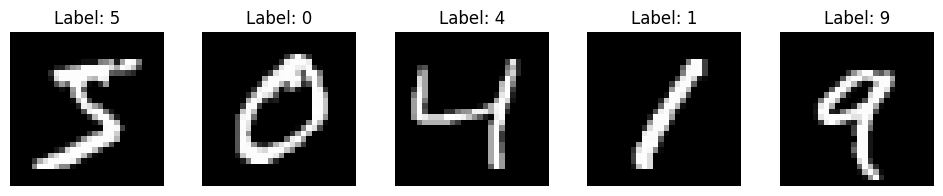

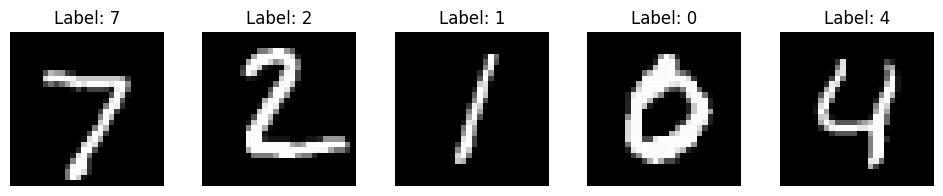

In [4]:
# @title ## データの準備（第7章と同じ）
# MNISTデータセットの読み込み
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
# データの正規化
x_train = x_train / 255.0
x_test = x_test / 255.0

# データの確認
print("学習用画像の形状: ", x_train.shape)
print("学習用ラベルの形状: ", y_train.shape)
print("検証用画像の形状: ", x_test.shape)
print("検証用ラベルの形状: ", y_test.shape)

# データの可視化
def plot_sample_images(images, labels, num_samples):
    plt.figure(figsize=(12, 2))
    for i in range(num_samples):
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(images[i], cmap='gray')
        plt.title(f"Label: {labels[i]}")
        plt.axis('off')
    plt.show()

# 学習用データから5個のサンプルを表示
plot_sample_images(x_train, y_train, num_samples=5)
# 検証用データから5個のサンプルを表示
plot_sample_images(x_test, y_test, num_samples=5)

In [5]:
# @title ## 学習用/検証用データに含まれる各ラベルの枚数を確認（第7章と同じ）
# 各ラベルの数を計算する関数
def count_labels(y):
    unique, counts = np.unique(y, return_counts=True)
    return dict(zip(unique, counts))

# 学習用データと検証用データのラベル数を計算
train_label_counts = count_labels(y_train)
test_label_counts = count_labels(y_test)

# データフレームにまとめる
df = pd.DataFrame({
    'ラベル': list(train_label_counts.keys()),
    '学習用データの数': list(train_label_counts.values()),
    '検証用データの数': [test_label_counts.get(label, 0) for label in train_label_counts.keys()]
})

# データフレームを表示
df

,ラベル,学習用データの数,検証用データの数
0,0,5923,980
1,1,6742,1135
2,2,5958,1032
3,3,6131,1010
4,4,5842,982
5,5,5421,892
6,6,5918,958
7,7,6265,1028
8,8,5851,974
9,9,5949,1009


## VAEを動かしてみよう

--2025-06-16 17:23:09--  https://raw.githubusercontent.com/liber-craft-co-ltd/book_impress_it-basic-education-ai/master/chap08_vae_mnist.h5
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2910080 (2.8M) [application/octet-stream]
Saving to: ‘chap08_vae_mnist.h5’

chap08_vae_mnist.h5 100%[===================>]   2.77M  --.-KB/s    in 0.01s   

2025-06-16 17:23:09 (215 MB/s) - ‘chap08_vae_mnist.h5’ saved [2910080/2910080]

--2025-06-16 17:23:09--  https://raw.githubusercontent.com/liber-craft-co-ltd/book_impress_it-basic-education-ai/master/chap08_vae_encoder_mnist.h5
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.1

Model: "variational_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_28 (InputLayer)     │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_model (Functional)      │ [(None, 2), (None, 2), │       100,996 │
│                                 │ (None, 2)]             │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_model (Functional)      │ (None, 784)            │       101,520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 202,516 (791.08 KB)

 Trainable params: 202,516 (791.08 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_31 (InputLayer)     │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Sequential)            │ (None, 784)            │       101,520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,520 (396.56 KB)

 Trainable params: 101,520 (396.56 KB)

 Non-trainable params: 0 (0.00 B)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


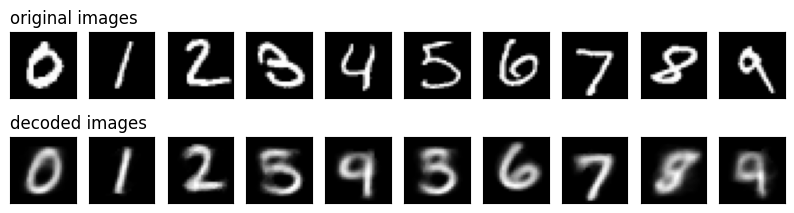

In [19]:
# Reparametrization Trick (モデルの読み込み時に必要なので再定義)
# VAEの学習部分で定義されたsampling関数と同じである必要があります。
def sampling(args):
    z_mean, z_logvar = args
    # Use tf.shape instead of K.shape
    batch = tf.shape(z_mean)[0]
    dim = tf.shape(z_mean)[1] # Also use tf.shape here
    # Use tf.random.normal instead of K.random_normal
    epsilon = tf.random.normal(shape=(batch, dim), seed = 5)
    # Use tf.exp instead of K.exp
    return z_mean + tf.exp(0.5 * z_logvar) * epsilon

# Define the VAE model structure based on the "参考：自分でVAEを定義して学習する" section
# 画像のサイズを指定
image_size = 28
# 画像を1次元に変換
original_dim = 28*28
# 入力データの形状
input_shape = (original_dim,)
# 潜在変数の次元数
latent_dim = 2

# VAEモデル構築
inputs = Input(shape=input_shape)

encoder = Sequential([
    Dense(128, activation='relu', input_shape=input_shape),
    Dense(latent_dim + latent_dim)
], name='encoder')

# Define how z_mean, z_logvar, and z are obtained from the encoder output
encoder_output = encoder(inputs)
z_mean = encoder_output[:, :latent_dim]
z_logvar = encoder_output[:, latent_dim:]
z = Lambda(sampling, output_shape=(latent_dim,))([z_mean, z_logvar])

# Define the models
encoder_model = Model(inputs, [z_mean, z_logvar, z], name='encoder_model')

decoder = Sequential([
    Dense(128, activation='relu', input_shape=(latent_dim,)),
    Dense(original_dim, activation='sigmoid')
], name='decoder')

latent_inputs = Input(shape=(latent_dim,))
outputs = decoder(latent_inputs)

decoder_model = Model(latent_inputs, outputs, name='decoder_model')

z_output = encoder_model(inputs)[2] # Use the output z from the encoder_model
outputs = decoder_model(z_output)
vae = Model(inputs, outputs, name='variational_autoencoder')


# 指定されたURLから学習済みモデルをダウンロードして保存
!wget -O chap08_vae_mnist.h5 https://raw.githubusercontent.com/liber-craft-co-ltd/book_impress_it-basic-education-ai/master/chap08_vae_mnist.h5
!wget -O chap08_vae_encoder_mnist.h5 https://raw.githubusercontent.com/liber-craft-co-ltd/book_impress_it-basic-education-ai/master/chap08_vae_encoder_mnist.h5
!wget -O chap08_vae_decoder_mnist.h5 https://raw.githubusercontent.com/liber-craft-co-ltd/book_impress_it-basic-education-ai/master/chap08_vae_decoder_mnist.h5

# ダウンロードしたファイルの重みを、定義したモデルに読み込む
# By loading weights, we don't need Keras to deserialize the architecture
# vae.load_weights('chap08_vae_mnist.h5', skip_mismatch=True) # <-- Remove this line
encoder_model.load_weights('chap08_vae_encoder_mnist.h5')
decoder_model.load_weights('chap08_vae_decoder_mnist.h5')

# モデルの構造を表示
vae.summary()
encoder_model.summary()
decoder_model.summary()

# Reshape x_test back to its original shape (28, 28) before using it in predict
# The loaded VAE expects input in (None, 784) shape, so reshape x_test before prediction
x_test_reshaped = x_test.reshape(-1, original_dim)

# テスト画像を変換
decoded_imgs = vae.predict(x_test_reshaped)

# ０～９までの数字のインデックスを定義
digit_index_list = [3,2,1,18,4,15,11,0,61,7]
# 各行のラベルを設定
labels = ["original images", "decoded images"]
plt.figure(figsize=(10, 2.5))
# 各行にラベルを付ける
for row, label in enumerate(labels):
    ax = plt.subplot(2, len(digit_index_list), row * len(digit_index_list) + 1)
    ax.set_title(label, loc='left')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

for i, digit_index in enumerate(digit_index_list):
    # テスト画像を表示
    ax = plt.subplot(2, len(digit_index_list), i+1)
    # Use the original x_test shape (28, 28) for display
    plt.imshow(x_test[digit_index].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # 変換された画像を表示
    ax = plt.subplot(2, len(digit_index_list), i+1+len(digit_index_list))
    plt.imshow(decoded_imgs[digit_index].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


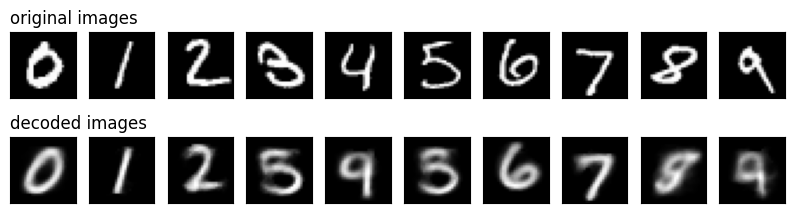

In [20]:
# テスト画像を変換
decoded_imgs = vae.predict(x_test.reshape(-1, 28*28))

# ０～９までの数字のインデックスを定義
digit_index_list = [3,2,1,18,4,15,11,0,61,7]
# 各行のラベルを設定
labels = ["original images", "decoded images"]
plt.figure(figsize=(10, 2.5))
# 各行にラベルを付ける
for row, label in enumerate(labels):
    ax = plt.subplot(2, len(digit_index_list), row * len(digit_index_list) + 1)
    ax.set_title(label, loc='left')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

for i, digit_index in enumerate(digit_index_list):
    # テスト画像を表示
    ax = plt.subplot(2, len(digit_index_list), i+1)
    plt.imshow(x_test[digit_index].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # 変換された画像を表示
    ax = plt.subplot(2, len(digit_index_list), i+1+len(digit_index_list))
    plt.imshow(decoded_imgs[digit_index].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

### 潜在空間を可視化してみる

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


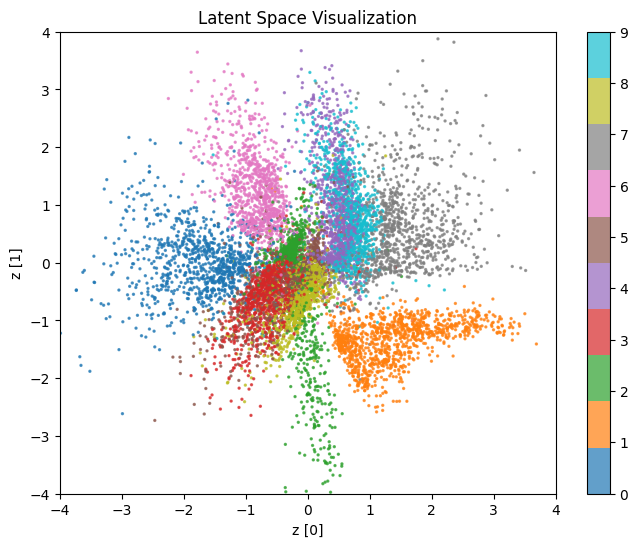

In [21]:
import matplotlib.cm as cm
def plot_results(encoder_model,
                 decoder_model,
                 x_test,
                 y_test,
                 batch_size=128,
                 model_name="vae_mnist"):
    # encoder_model.predictがリストを返す場合は、最初の要素をz_meanとして使用
    z_mean, _, _ = encoder_model.predict(x_test)
    plt.figure(figsize=(8, 6))
    plt.scatter(z_mean[:, 0], z_mean[:, 1], c=y_test, s=2, alpha=0.7,cmap='tab10')
    plt.colorbar()
    plt.xlabel("z [0]")
    plt.ylabel("z [1]")
    plt.xlim(-4, 4)
    plt.ylim(-4, 4)
    plt.title('Latent Space Visualization')
    plt.show()

plot_results(encoder_model,
             decoder_model,
             x_test.reshape(-1, 28*28),
             y_test,
             model_name="vae_mlp")


In [22]:
# @title ### 参考：画像を保存してZIP化
# Directory to save the images
import os
output_dir_test = './my_autoencoder'
output_dir_decoded = './my_autoencoder'
os.makedirs(output_dir_test, exist_ok=True)
os.makedirs(output_dir_decoded, exist_ok=True)

# Loop through the digit index list and save each image separately
for i, digit_index in enumerate(digit_index_list):
    # Save test image
    plt.figure(figsize=(10, 10))
    plt.imshow(x_test[digit_index].reshape(28, 28))
    plt.gray()
    plt.axis('off')
    plt.savefig(os.path.join(output_dir_test, f'test_image_{i}.png'))
    plt.close()

    # Save decoded image
    plt.figure(figsize=(10, 10))
    plt.imshow(decoded_imgs[digit_index].reshape(28, 28))
    plt.gray()
    plt.axis('off')
    plt.savefig(os.path.join(output_dir_decoded, f'decoded_image_{i}.png'))
    plt.close()

# List the saved files for confirmation
saved_files_test = os.listdir(output_dir_test)
saved_files_decoded = os.listdir(output_dir_decoded)
saved_files_test, saved_files_decoded
!zip -r ./my_autoencoder.zip ./my_autoencoder

  adding: my_autoencoder/ (stored 0%)
  adding: my_autoencoder/test_image_3.png (deflated 78%)
  adding: my_autoencoder/decoded_image_8.png (deflated 71%)
  adding: my_autoencoder/decoded_image_7.png (deflated 74%)
  adding: my_autoencoder/decoded_image_6.png (deflated 73%)
  adding: my_autoencoder/decoded_image_4.png (deflated 74%)
  adding: my_autoencoder/test_image_8.png (deflated 79%)
  adding: my_autoencoder/test_image_6.png (deflated 78%)
  adding: my_autoencoder/test_image_2.png (deflated 80%)
  adding: my_autoencoder/test_image_4.png (deflated 81%)
  adding: my_autoencoder/test_image_0.png (deflated 79%)
  adding: my_autoencoder/decoded_image_9.png (deflated 73%)
  adding: my_autoencoder/test_image_1.png (deflated 85%)
  adding: my_autoencoder/decoded_image_2.png (deflated 74%)
  adding: my_autoencoder/decoded_image_5.png (deflated 72%)
  adding: my_autoencoder/decoded_image_3.png (deflated 72%)
  adding: my_autoencoder/test_image_7.png (deflated 82%)
  adding: my_autoencoder/d

# 参考：自分でVAEを定義して学習する

In [37]:
# @title ## VAEの定義と学習
# @markdown - このコードセルを実行すると、VAEを構築して10エポックだけ学習します（時間がかかります）

# === VAE (Keras 3 + TF backend) =============================================
import tensorflow as tf
from keras import layers, models, losses

# 1. データ準備 (MNIST) -------------------------------------------------------
from keras.datasets import mnist
(x_train, _), (x_test, _) = mnist.load_data()

orig_dim   = 28 * 28      # 784
latent_dim = 2
x_train = x_train.reshape(-1, orig_dim).astype("float32") / 255.0
x_test  = x_test.reshape(-1, orig_dim).astype("float32")  / 255.0

# 2. Sampling Layer ----------------------------------------------------------
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_logvar = inputs
        eps = tf.random.normal(shape=tf.shape(z_mean), seed=42)
        z   = z_mean + tf.exp(0.5 * z_logvar) * eps
        kl  = -0.5 * tf.reduce_sum(
                1 + z_logvar - tf.square(z_mean) - tf.exp(z_logvar), axis=-1
              )
        self.add_loss(tf.reduce_mean(kl))
        return z

# 3. Encoder -----------------------------------------------------------------
enc_in  = layers.Input(shape=(orig_dim,))
x       = layers.Dense(128, activation="relu")(enc_in)
z_mean  = layers.Dense(latent_dim, name="z_mean")(x)
z_logvar= layers.Dense(latent_dim, name="z_logvar")(x)
z       = Sampling()([z_mean, z_logvar])

encoder = models.Model(enc_in, [z_mean, z_logvar, z], name="encoder")
encoder.summary()

# 4. Decoder -----------------------------------------------------------------
dec_in  = layers.Input(shape=(latent_dim,))
y       = layers.Dense(128, activation="relu")(dec_in)
dec_out = layers.Dense(orig_dim, activation="sigmoid")(y)

decoder = models.Model(dec_in, dec_out, name="decoder")
decoder.summary()

# 5. VAE 全体 ----------------------------------------------------------------
vae_out = decoder(z)
vae = models.Model(enc_in, vae_out, name="vae")

vae.compile(
    optimizer="adam",
    loss=losses.MeanSquaredError()        # 再構成誤差のみ指定
)

# 6. 学習 --------------------------------------------------------------------
vae.fit(
    x_train, x_train,            # 入力＝教師信号
    epochs=10,
    batch_size=128,
    validation_data=(x_test, x_test)
)


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_76      │ (None, 784)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_79 (Dense)    │ (None, 128)       │    100,480 │ input_layer_76[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │        258 │ dense_79[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_logvar (Dense)    │ (None, 2)         │        258 │ dense_79[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling_2          │ (None, 2)         │          0 │ z_mean[0][0],     │
│ (Sampling)          │                   │            │ z_logvar[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 100,996 (394.52 KB)

 Trainable params: 100,996 (394.52 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_77 (InputLayer)     │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_80 (Dense)                │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_81 (Dense)                │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,520 (396.56 KB)

 Trainable params: 101,520 (396.56 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.1355 - val_loss: 0.0685
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0680 - val_loss: 0.0678
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0675 - val_loss: 0.0676
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0674 - val_loss: 0.0676
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0673 - val_loss: 0.0676
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0673 - val_loss: 0.0676
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0673 - val_loss: 0.0675
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0673 - val_loss: 0.0675
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0673 - val_loss: 0.0675
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0673 - val_loss: 0.0675
